In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import drug2cell as d2c
import numpy as np
import matplotlib.pyplot as plt

In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
plt.rcParams["pdf.fonttype"] = "truetype"
plt.rcParams["axes.grid"] = False

In [6]:
adata_full = sc.read_h5ad("data/adata_with_signatures_and_hotspots.h5ad")

In [7]:
adata = adata_full.copy()

In [8]:
# Cell type labels
cell_type_labels = [
    "B cells Memory",
    "B cells Naive",
    "CAFs MSC iCAF-like s1",
    "CAFs MSC iCAF-like s2",
    "CAFs Transitioning s3",
    "CAFs myCAF like s4",
    "CAFs myCAF like s5",
    "Cycling PVL",
    "Cycling_Myeloid",
    "Endothelial ACKR1",
    "Endothelial CXCL12",
    "Endothelial Lymphatic LYVE1",
    "Endothelial RGS5",
    "Myeloid_c0_DC_LAMP3",
    "Myeloid_c10_Macrophage_1_EGR1",
    "Myeloid_c11_cDC2_CD1C",
    "Myeloid_c12_Monocyte_1_IL1B",
    "Myeloid_c1_LAM1_FABP5",
    "Myeloid_c2_LAM2_APOE",
    "Myeloid_c3_cDC1_CLEC9A",
    "Myeloid_c4_DCs_pDC_IRF7",
    "Myeloid_c5_Macrophage_3_SIGLEC1",
    "Myeloid_c7_Monocyte_3_FCGR3A",
    "Myeloid_c8_Monocyte_2_S100A9",
    "Myeloid_c9_Macrophage_2_CXCL10",
    "PVL Differentiated s3",
    "PVL Immature s1",
    "PVL_Immature s2",
    "Plasmablasts",
    "T_cells_c0_CD4+_CCR7",
    "T_cells_c10_NKT_cells_FCGR3A",
    "T_cells_c11_MKI67",
    "T_cells_c1_CD4+_IL7R",
    "T_cells_c2_CD4+_T-regs_FOXP3",
    "T_cells_c3_CD4+_Tfh_CXCL13",
    "T_cells_c4_CD8+_ZFP36",
    "T_cells_c5_CD8+_GZMK",
    "T_cells_c6_IFIT1",
    "T_cells_c7_CD8+_IFNG",
    "T_cells_c8_CD8+_LAG3",
    "T_cells_c9_NK_cells_AREG",
    "G0_arrested",
    "Fast_cycling",
]

quiescence_labels = ["G0_arrested", "Fast_cycling"]

cell_type_labels_hotspots = [label + "_hot" for label in cell_type_labels]

adata.obs["cell_type"] = adata.obs[cell_type_labels_hotspots].idxmax(axis=1)
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

In [9]:
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
adata.obs["cell_type"] = adata.obs["cell_type"].cat.add_categories("Slow_cycling_hot")
adata.obs.loc[
    (adata.obs["tumour_cells"] == 1)
    & (~adata.obs["cell_type"].isin(["G0_arrested_hot", "Fast_cycling_hot"])),
    "cell_type",
] = "Slow_cycling_hot"
adata = adata[adata.obs["tumour_cells"] == 1].copy()

In [10]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

normalizing counts per cell
    finished (0:00:00)


In [11]:
sc.pp.highly_variable_genes(adata, subset=True, flavor="cell_ranger")

extracting highly variable genes
    finished (0:00:00)


In [12]:
d2c.score(adata, use_raw=False)

In [13]:
sc.tl.rank_genes_groups(adata.uns["drug2cell"], method="wilcoxon", groupby="cell_type", use_raw=False)

ranking genes
    finished (0:00:02)


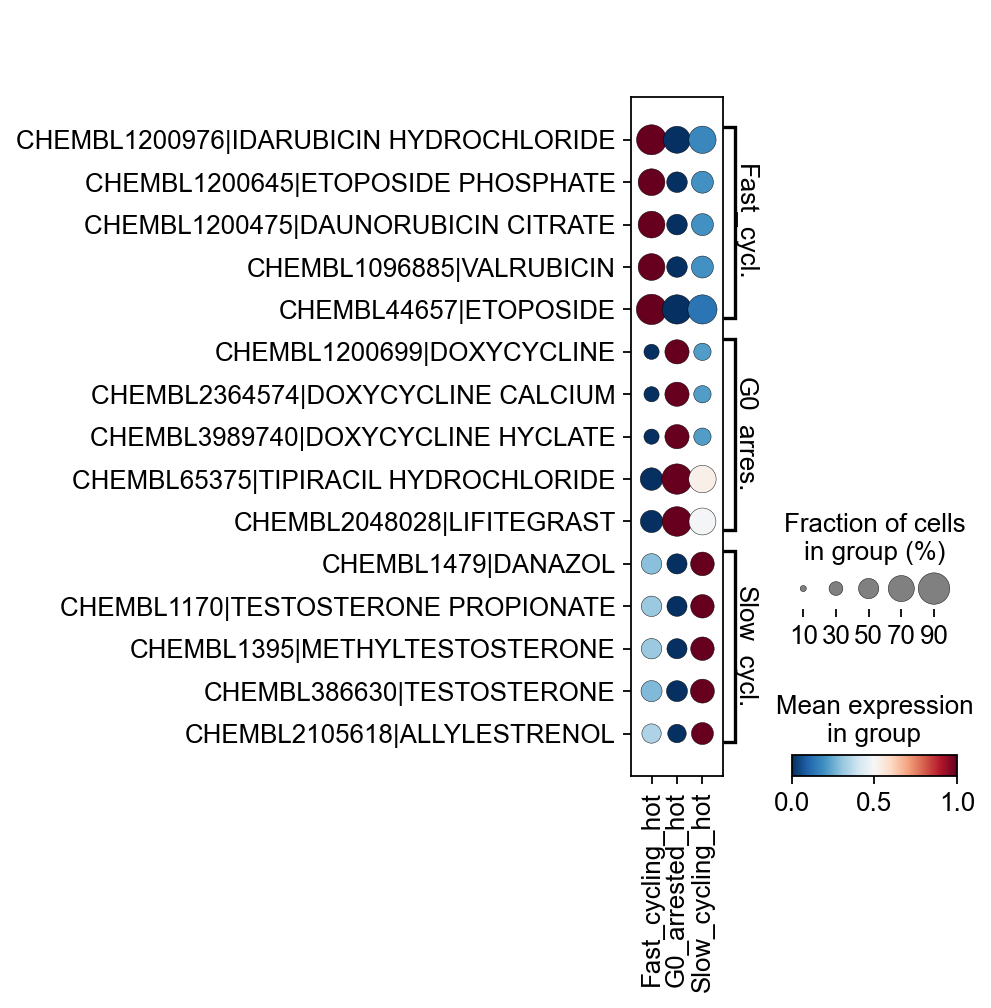

In [14]:
sc.pl.rank_genes_groups_dotplot(
    adata.uns["drug2cell"],
    n_genes=5,
    swap_axes=True,
    dendrogram=False,
    cmap="RdBu_r",
    groupby="cell_type",
    standard_scale="var",
    save="drug2cell_spatial_dotplot_cycling_state.pdf",
)

In [15]:
adata.write_h5ad("data/adata_with_drug2cell_scores.h5ad")